In [13]:
from spiderstate.cat_at_origin import *
from spidercat.draw import draw_forest_on_graph
from spiderstate.utils import load_qecc

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[[0 0 0 0 1 1 1 1 0 0 0 0]
 [0 1 1 0 1 0 1 0 1 1 0 0]
 [1 0 1 0 0 0 1 1 0 1 1 0]
 [0 0 1 1 1 0 0 1 1 0 1 0]
 [0 0 0 0 0 0 0 0 1 1 1 1]]
RX 0 1
R 2
RX 3
R 4
RX 5
R 6 7 8 9 10
RX 11
R 12
CX 0 12
R 13
CX 1 13
RX 14
CX 14 2
R 15
CX 3 15
RX 16
CX 16 4
R 17
CX 5 17
RX 18
CX 18 6
RX 19
CX 19 7
RX 20
CX 20 8
RX 21
CX 21 9
RX 22
CX 22 10
R 23
CX 11 23 1 16 5 4 17 6 13 18 11 8 23 9 3 16 1 20 0 18 17 7 13 21 23 10 16 4
MX 16
CX 3 19 15 20 18 6
MX 18
CX 5 17
M 17
CX 13 2 12 21 11 23
M 23
CX 0 19 20 8
MX 20
CX 15 22 1 13
M 13
CX 21 9
MX 21
CX 19 7
MX 19
CX 15 14 12 22 3 15
M 15
CX 22 10
MX 22
CX 12 14 0 12
M 12
CX 14 2
MX 14
DETECTOR rec[-12]
DETECTOR rec[-11]
DETECTOR rec[-10]
DETECTOR rec[-9]
DETECTOR rec[-8]
DETECTOR rec[-7]
DETECTOR rec[-6]
DETECTOR rec[-5]
DETECTOR rec[-4]
DETECTOR rec[-3]
DETECTOR rec[-2]
DETECTOR rec[-1]


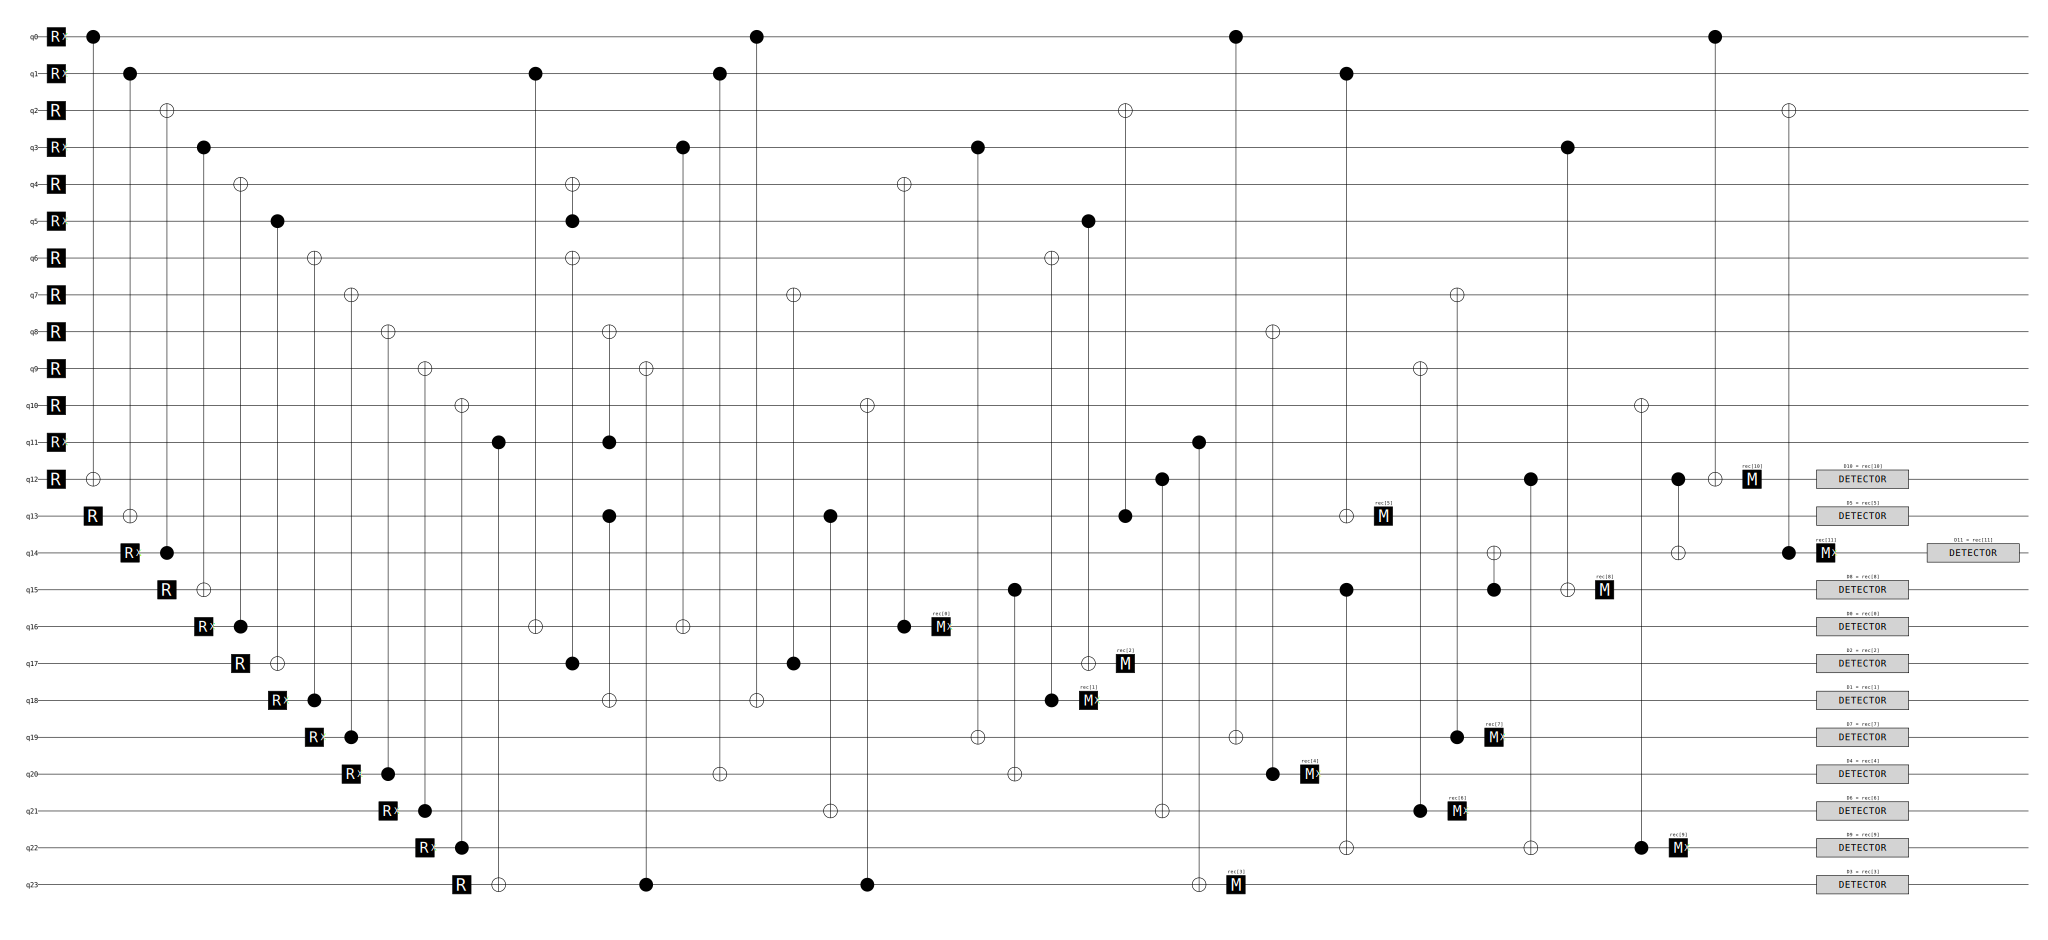

In [17]:
is_self_dual, H_x, H_z, L_x, L_z, d = load_qecc("12_2_4", "MQT")
t = d // 2

row_M, final_M, col_ops = optimize_fault_tolerant_matrix(H_z, t=t, max_col_ops=10, max_basis_tries=10_000)
print(row_M, sep="\n\n")

circ = cat_at_origin(row_M, d)
print(circ)
circ.diagram('timeline-svg')

In [22]:
circuit = circ.copy()
circuit.append("M", range(H_x.shape[1]))
samples = circuit.compile_sampler().sample(10)
meas_samples = samples[:,-H_z.shape[1]:]
print(meas_samples @ H_x.T % 2)
print(meas_samples @ L_x.T % 2)

[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]
[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]]


In [4]:
from spidercat.simulate import _layer_cnot_circuit

raw_cnots = [l for (name, l, _) in circ.flattened_operations() if name == "CX"]
cnots = [(ops[i], ops[i + 1]) for ops in raw_cnots for i in range(0, len(ops), 2)]
print("Num CX:", len(cnots))
print("Num Flags:", circ.num_qubits - H_x.shape[1])
print("Num qubits:", circ.num_qubits)
layered_cnots = _layer_cnot_circuit(cnots)
print("Depth:", len(layered_cnots))

Num CX: 46
Num Flags: 9
Num qubits: 24
Depth: 9
